In [1]:
import os, time, math, random
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 128
EPOCHS = 3        # corto para CPU
LR = 1e-3
SEED = 42
torch.manual_seed(SEED); random.seed(SEED)

# 1) Datos: Fashion-MNIST normalizado
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_full = datasets.FashionMNIST(root="data", train=True, download=True, transform=transform)
test = datasets.FashionMNIST(root="data", train=False, download=True, transform=transform)

# Subconjunto para ir rápido (10k train, 2k val)
idx_train = list(range(10000))
idx_val = list(range(2000))
train = Subset(train_full, idx_train)
val = Subset(train_full, idx_val)

dl_train = DataLoader(train, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
dl_val = DataLoader(val, batch_size=BATCH_SIZE, shuffle=False)

# 2) Modelo: MLP sencillo
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 10)
        )
    def forward(self, x):
        return self.net(x)

def run_experiment(optimizer_name="adam", lr=LR, betas=(0.9, 0.999), alpha=0.99, weight_decay=0.0):
    model = MLP().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    if optimizer_name.lower() == "adam":
        opt = optim.Adam(model.parameters(), lr=lr, betas=betas, weight_decay=weight_decay)
    elif optimizer_name.lower() == "rmsprop":
        opt = optim.RMSprop(model.parameters(), lr=lr, alpha=alpha, weight_decay=weight_decay)
    else:
        raise ValueError("optimizer_name debe ser 'adam' o 'rmsprop'")

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    start = time.time()
    for epoch in range(1, EPOCHS+1):
        model.train()
        running = 0.0
        for x, y in dl_train:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)  # estabiliza
            opt.step()
            running += loss.item()
        train_loss = running / len(dl_train)

        # Validación
        model.eval()
        vloss = 0.0; correct = 0; total = 0
        with torch.no_grad():
            for x, y in dl_val:
                x, y = x.to(DEVICE), y.to(DEVICE)
                logits = model(x)
                loss = criterion(logits, y)
                vloss += loss.item()
                pred = logits.argmax(dim=1)
                correct += (pred == y).sum().item()
                total += y.size(0)
        val_loss = vloss / len(dl_val)
        val_acc = correct / total
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"[{optimizer_name.upper()}] epoch {epoch}/{EPOCHS} "
              f"train_loss={train_loss:.3f} val_loss={val_loss:.3f} val_acc={val_acc:.3f}")
    elapsed = time.time() - start
    print(f"Tiempo total ({optimizer_name}): {elapsed:.1f}s")
    return history, elapsed

if __name__ == "__main__":
    # Exp-1: Adam (lr=1e-3, betas=(0.9,0.999))
    h_adam, t_adam = run_experiment("adam", lr=1e-3, betas=(0.9, 0.999))
    # Exp-2: RMSProp (lr=1e-3, alpha=0.99)
    h_rms, t_rms = run_experiment("rmsprop", lr=1e-3, alpha=0.99)

    # TODO: graficar curvas (usa matplotlib) y comparar tiempos/accuracies.
    # Tip: plt.plot(range(1,EPOCHS+1), h_adam["val_acc"], label="Adam") etc.


100%|██████████| 26.4M/26.4M [00:05<00:00, 5.15MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 199kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.45MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.6MB/s]


[ADAM] epoch 1/3 train_loss=0.771 val_loss=0.484 val_acc=0.824
[ADAM] epoch 2/3 train_loss=0.483 val_loss=0.437 val_acc=0.846
[ADAM] epoch 3/3 train_loss=0.413 val_loss=0.360 val_acc=0.875
Tiempo total (adam): 16.8s
[RMSPROP] epoch 1/3 train_loss=0.976 val_loss=0.520 val_acc=0.803
[RMSPROP] epoch 2/3 train_loss=0.504 val_loss=0.479 val_acc=0.819
[RMSPROP] epoch 3/3 train_loss=0.440 val_loss=0.357 val_acc=0.870
Tiempo total (rmsprop): 14.4s


Gráficas guardadas: val_acc.png, val_loss.png


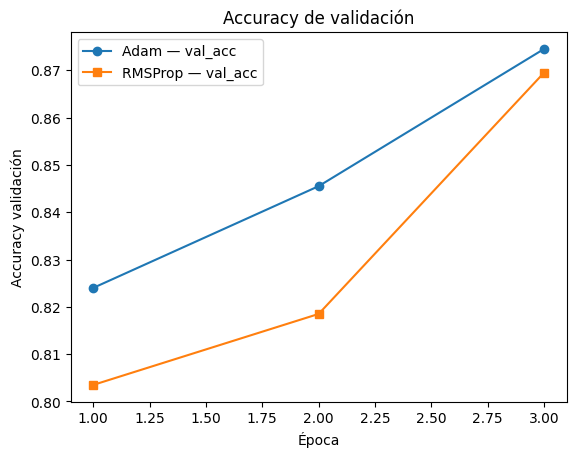

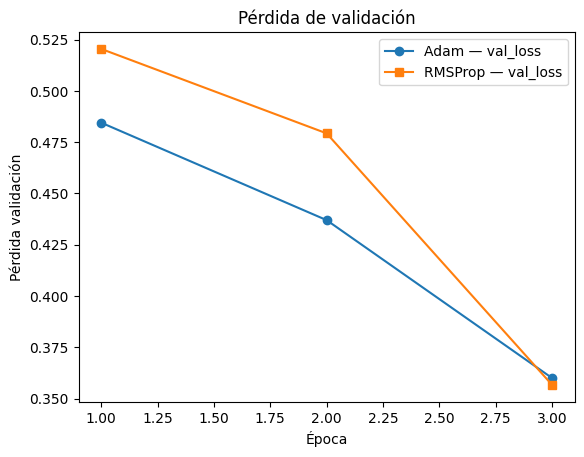

In [3]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(range(1, EPOCHS+1), h_adam["val_acc"], marker="o", label="Adam — val_acc")
plt.plot(range(1, EPOCHS+1), h_rms["val_acc"], marker="s", label="RMSProp — val_acc")
plt.xlabel("Época"); plt.ylabel("Accuracy validación"); plt.legend(); plt.title("Accuracy de validación")
plt.savefig("val_acc.png", dpi=150)

plt.figure()
plt.plot(range(1, EPOCHS+1), h_adam["val_loss"], marker="o", label="Adam — val_loss")
plt.plot(range(1, EPOCHS+1), h_rms["val_loss"], marker="s", label="RMSProp — val_loss")
plt.xlabel("Época"); plt.ylabel("Pérdida validación"); plt.legend(); plt.title("Pérdida de validación")
plt.savefig("val_loss.png", dpi=150)
print("Gráficas guardadas: val_acc.png, val_loss.png")
